In [28]:
!pip install gensim
!pip install nltk

In [44]:
from google.colab import drive
!git clone https://github.com/fabianagoes/ismb_tutorial8.git
%cd ismb_tutorial8
drive.mount('/content/drive')
import os
from gensim.models import Word2Vec
import pandas as pd
import numpy as np
from utils import *
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns

Cloning into 'ismb_tutorial8'...
remote: Enumerating objects: 266, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 266 (delta 43), reused 45 (delta 19), pack-reused 193 (from 1)
Receiving objects: 100% (266/266), 54.06 MiB | 16.53 MiB/s, done.
Resolving deltas: 100% (79/79), done.
Updating files: 100% (106/106), done.
/content/ismb_tutorial8/ismb_tutorial8/ismb_tutorial8/ismb_tutorial8/ismb_tutorial8/ismb_tutorial8/ismb_tutorial8/ismb_tutorial8
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
root_dir = "/content/ismb_tutorial8/datasets"
subdirs = get_all_subdirs(root_dir) # internal function that goes over all subdirectories. Source code: utils.py

dropdown = widgets.Dropdown(
    options=subdirs,
    description='Select:',
    disabled=False,
)

selected_path = {'value': subdirs[0]}

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        selected_path['value'] = change['new']

dropdown.observe(on_change)

display(dropdown)

Dropdown(description='Select:', options=('/content/ismb_tutorial8/datasets/GUE/virus/covid', '/content/ismb_tu…

In [23]:
print('Dataset Selected: ',selected_path['value'])

train_data=pd.read_csv(selected_path['value']+'/train.csv')#read_csv to read csv files
val_data=pd.read_csv(selected_path['value']+'/dev.csv')
test_data=pd.read_csv(selected_path['value']+'/test.csv')
data={'Train':train_data,'Val':val_data,'Test':test_data}
print("\nDetailed information:")
for name, dataset in data.items():
    print(f"{name}: {dataset.shape[0]} rows, {dataset.shape[1]} col")

print("\nShowing the first 5 train datapoints:")
train_data.head(5)

Dataset Selected:  /content/ismb_tutorial8/datasets/GUE/prom/prom_300_tata

Detailed information:
Train: 4904 rows, 2 col
Val: 613 rows, 2 col
Test: 613 rows, 2 col

Showing the first 5 train datapoints:


,sequence,label
0,CCAGGTCCCGGGAGCGCCACGGAACCTAACGGTGGCAGCGGAGGTC...,1
1,CCGGCCGAGCTCAGCACCGAGGCGCCCCCCAACCTGCCCAGCCCCC...,0
2,CACCTTGGACTTGGGACCAGAAAGAGGTGGGTTGGGTGAAGAGGCA...,1
3,CCTCCCTCCCCTAGAACACCCTCCTCATACCTGGCCTTTGGTCTTC...,1
4,CAATTTTGATTATCTGACAACATGATGTCCAAACTGAGGTATTTAT...,1


In [24]:
# Function to generate k-mers
def kmerize(sequence, k=3):
    return [sequence[i:i+k] for i in range(len(sequence)-k+1)]

# Create corpus for word2vec using training sequences
k = 3
corpus = [kmerize(seq, k) for seq in train_data['sequence']]

print(f"First {3} k-merized sequences (k={k}):")
print("-" * 60)

for i, kmers in enumerate(corpus[:3]):
    print(f"Sequence {i+1}:")
    print(f"  K-mers: {kmers}")
    print(f"  Number of k-mers: {len(kmers)}")
    print(f"  First 5 k-mers: {kmers[:5]}")
    print("-" * 60)

First 3 k-merized sequences (k=3):
------------------------------------------------------------
Sequence 1:
  K-mers: ['CCA', 'CAG', 'AGG', 'GGT', 'GTC', 'TCC', 'CCC', 'CCG', 'CGG', 'GGG', 'GGA', 'GAG', 'AGC', 'GCG', 'CGC', 'GCC', 'CCA', 'CAC', 'ACG', 'CGG', 'GGA', 'GAA', 'AAC', 'ACC', 'CCT', 'CTA', 'TAA', 'AAC', 'ACG', 'CGG', 'GGT', 'GTG', 'TGG', 'GGC', 'GCA', 'CAG', 'AGC', 'GCG', 'CGG', 'GGA', 'GAG', 'AGG', 'GGT', 'GTC', 'TCG', 'CGC', 'GCG', 'CGC', 'GCC', 'CCC', 'CCC', 'CCT', 'CTC', 'TCA', 'CAG', 'AGT', 'GTG', 'TGC', 'GCC', 'CCC', 'CCG', 'CGC', 'GCG', 'CGC', 'GCT', 'CTC', 'TCT', 'CTC', 'TCC', 'CCC', 'CCC', 'CCG', 'CGT', 'GTC', 'TCG', 'CGG', 'GGG', 'GGA', 'GAG', 'AGC', 'GCT', 'CTT', 'TTC', 'TCC', 'CCT', 'CTG', 'TGG', 'GGT', 'GTC', 'TCG', 'CGC', 'GCC', 'CCC', 'CCC', 'CCT', 'CTG', 'TGC', 'GCG', 'CGG', 'GGC', 'GCG', 'CGG', 'GGC', 'GCG', 'CGG', 'GGC', 'GCT', 'CTC', 'TCG', 'CGG', 'GGG', 'GGG', 'GGT', 'GTG', 'TGT', 'GTC', 'TCT', 'CTG', 'TGG', 'GGC', 'GCC', 'CCG', 'CGG', 'GGC', 'GCG', 'CGC',

In [38]:
# Train the word2vec model
w2v_model = Word2Vec(sentences=corpus, vector_size=250, window=5, min_count=1, workers=2, epochs=10)

print("Word2Vec Model Information:")
print("=" * 50)

# Informações básicas do modelo
print(f"Vocabulary size: {len(w2v_model.wv)}")
print(f"Vector dimensions: {w2v_model.wv.vector_size}")
print(f"Window size: {w2v_model.window}")
print(f"Min count: {w2v_model.min_count}")
print(f"Training epochs: {w2v_model.epochs}")

# Show vector of first k-mer of first sequence
example_kmer = corpus[0][0]
print(f"Vetor embedding para {example_kmer}:")
print(w2v_model.wv[example_kmer])

print("Example of vectors for k-mer 'ATC':")
print(w2v_model.wv['ATC'])  # replace with a k-mer present in your dataset

Word2Vec Model Information:
Vocabulary size: 64
Vector dimensions: 250
Window size: 5
Min count: 1
Training epochs: 10
Vetor embedding para CCA:
[ 0.03773133 -0.17757985  0.6079201   0.5540499  -0.6202501   0.3587294
  0.32647365 -0.36193463 -0.1141981   1.0827544  -0.96216697  0.59084815
  0.5043683  -0.24030821  0.9570466   1.1151193  -0.30923292  0.27635413
 -1.0128816  -0.3747575  -1.2604555  -0.03259035 -0.28854585  0.63487566
  0.03487097 -0.8715723   0.25767747 -0.31139526  0.7636761  -0.9851549
  0.5017123   0.23973168 -0.91485757  0.86888015 -0.24164456 -0.92226666
 -0.09195624 -0.47702783  0.49343836 -1.0382845  -0.41790938  0.5429222
  0.6645503  -0.06996161 -0.16849093 -0.25888902  0.35751262 -0.39181325
  0.29939646 -0.8652356   0.04742962 -0.17356949 -0.48042604 -1.1250037
  0.10872807 -0.45226583 -0.1585493   0.2736507   0.5347348  -1.4035126
  1.0837355  -0.31952405 -0.07656012  1.4170533  -0.10702377  0.62762684
  0.06366552 -0.8202491   0.20009342 -0.809962   -1.10291

In [39]:
# Show the most similar k-mers
print("K-mers mais similares to: ", example_kmer)
print(w2v_model.wv.most_similar(example_kmer))

K-mers mais similares to:  CCA
[('GCA', 0.47819122672080994), ('TCA', 0.46030980348587036), ('CCC', 0.44546598196029663), ('CCT', 0.4400659501552582), ('ACA', 0.3515639007091522), ('CCG', 0.27367955446243286), ('CTC', 0.1775510311126709), ('CGC', 0.16933105885982513), ('CGA', 0.12438102066516876), ('CTG', 0.11241315305233002)]


In [40]:
# Function to compute the average embedding for a list of k-mers
def sequence_vector(kmers, model):
    vectors = [model.wv[kmer] for kmer in kmers if kmer in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)  # or np.full(model.vector_size, np.nan)

# Generate embeddings directly from the corpus (do not modify train_data)
train_embeddings = np.array([sequence_vector(kmers, w2v_model) for kmers in corpus])
pd.DataFrame(train_embeddings).head()

,0,1,2,3,4,5,6,7,8,9,...,240,241,242,243,244,245,246,247,248,249
0,0.429091,-0.019131,0.014383,0.252146,-0.146794,0.090671,-0.269873,0.099529,-0.323787,0.193062,...,0.095973,-0.471024,0.299031,0.310181,0.069400,0.032533,0.063191,-0.310867,-0.100428,-0.070948
1,0.294546,-0.017805,0.008651,0.184510,-0.119829,0.080401,-0.117227,0.021387,-0.215654,0.155639,...,0.024192,-0.236492,0.138064,0.175515,0.061358,0.074615,0.018501,-0.155273,-0.082554,-0.035983
2,-0.023315,-0.101226,-0.009580,-0.119929,-0.115804,-0.008817,0.032559,0.006387,0.031714,-0.024517,...,-0.202977,0.208567,-0.034480,-0.097277,-0.091144,-0.000303,-0.054911,0.025507,-0.011336,0.048883
3,0.111202,-0.014689,0.046597,0.003693,-0.055858,-0.016401,-0.002748,0.025158,-0.151857,0.194432,...,-0.003654,-0.078172,0.050446,0.117180,0.047666,0.070140,-0.053944,-0.090835,-0.100378,0.005434
4,-0.249919,-0.004203,-0.056485,-0.149094,0.001825,-0.028575,0.167787,-0.094122,0.125612,-0.149172,...,-0.044484,0.245776,-0.127552,-0.156489,-0.021355,-0.022970,0.017325,0.083584,0.070970,0.063215


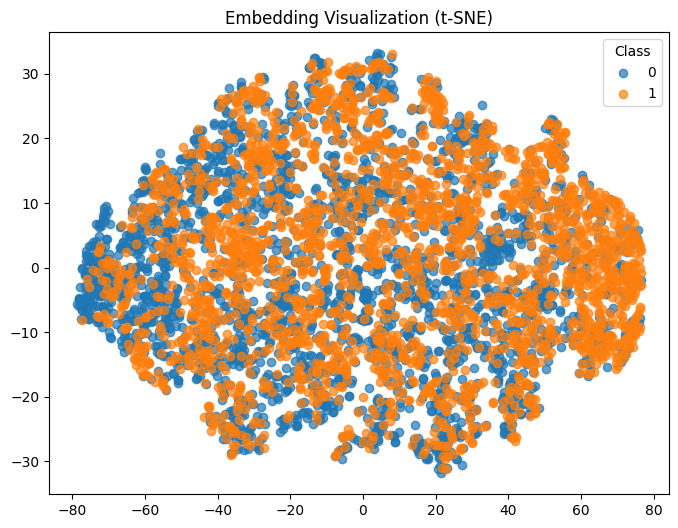

In [43]:
# Get the embeddings and labels
X = train_embeddings  # shape: (n_samples, embedding_dim)
y = train_data['label'].values  # labels from your original dataframe

# Reduce dimensionality to 2D using t-SNE
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_embedded = tsne.fit_transform(X)

# Create the plot
plt.figure(figsize=(8, 6))
classes = np.unique(y)
colors = plt.cm.tab10.colors  # or any other colormap

for i, cls in enumerate(classes):
    idx = y == cls
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1], color=colors[i % len(colors)], label=str(cls), alpha=0.7)

plt.title('Embedding Visualization (t-SNE)')
plt.legend(title='Class')
plt.show()

In [45]:
# Prepare feature matrices and labels for Machine Learning
def generate_embeddings(df, seq_col, w2v_model, k=3):
    embeddings_list = []
    for seq in df[seq_col]:
        kmers = kmerize(seq, k)
        vec = sequence_vector(kmers, w2v_model)
        embeddings_list.append(vec)

    return np.array(embeddings_list)

X_train = generate_embeddings(train_data, 'sequence', w2v_model, k=3)
y_train = train_data['label'].values

X_test = generate_embeddings(test_data, 'sequence', w2v_model, k=3)
y_test = test_data['label'].values

Random Forest Accuracy: 0.6492659053833605
              precision    recall  f1-score   support

           0       0.67      0.63      0.65       315
           1       0.63      0.66      0.65       298

    accuracy                           0.65       613
   macro avg       0.65      0.65      0.65       613
weighted avg       0.65      0.65      0.65       613



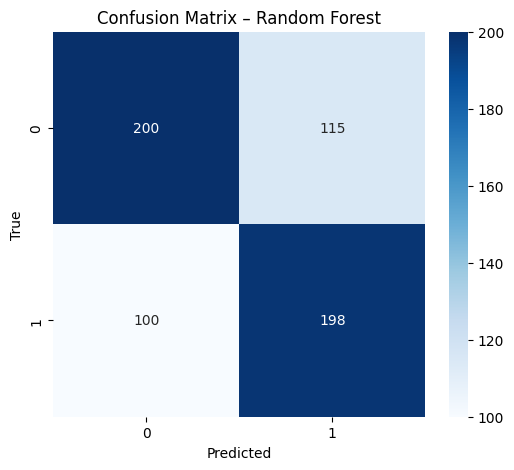

In [46]:
# ----- 1. Train a Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Neural Network Accuracy: 0.6639477977161501
              precision    recall  f1-score   support

           0       0.69      0.63      0.66       315
           1       0.64      0.70      0.67       298

    accuracy                           0.66       613
   macro avg       0.67      0.67      0.66       613
weighted avg       0.67      0.66      0.66       613



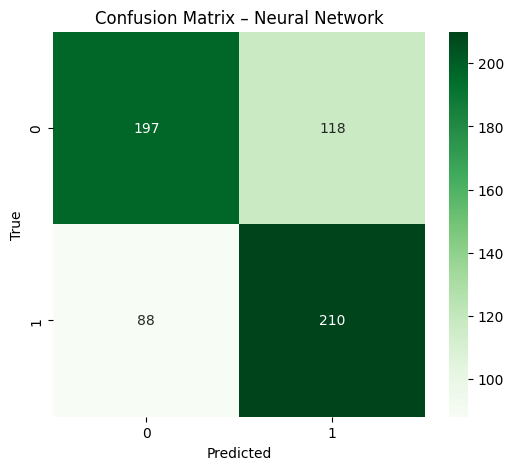

In [47]:
# ----- 2. Train a MLP (classic neural network) classifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu',
                    solver='adam', max_iter=300, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix – Neural Network")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()